# 2026 World Cup: Knockout Venue Analysis

All 32 knockout matches with pre-assigned cities, dates, and temperatures.


## 1. Full Knockout Venue Dataset

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_rows', None)
venues = pd.read_csv('../data/2026_knockout_venues.csv', parse_dates=['Date'])
venues['HOT_COLD'] = venues['City_Temp_C'].apply(lambda x: 'HOT' if x > 23 else 'COLD')
venues


,Date,Stage,Home_Slot,Away_Slot,City,City_Temp_C,Stadium,HOT_COLD
0,2026-06-28,Round of 32,Runner-up Group A,Runner-up Group B,Inglewood,19.8,SoFi Stadium,COLD
1,2026-06-29,Round of 32,Winner Group C,Runner-up Group F,Houston,28.3,NRG Stadium,HOT
2,2026-06-29,Round of 32,Winner Group E,3rd Group A/B/C/D/F,Foxborough,20.3,Gillette Stadium,COLD
3,2026-06-29,Round of 32,Winner Group F,Runner-up Group C,Guadalupe,28.8,Estadio BBVA,HOT
4,2026-06-30,Round of 32,Runner-up Group E,Runner-up Group I,Arlington,28.5,AT&T Stadium,HOT
5,2026-06-30,Round of 32,Winner Group I,3rd Group C/D/F/G/H,East Rutherford,22.5,MetLife Stadium,COLD
6,2026-06-30,Round of 32,Winner Group A,3rd Group C/E/F/H/I,Mexico City,17.6,Estadio Azteca,COLD
7,2026-07-01,Round of 32,Winner Group L,3rd Group E/H/I/J/K,Atlanta,25.4,Mercedes-Benz Stadium,HOT
8,2026-07-01,Round of 32,Winner Group G,3rd Group A/E/H/I/J,Seattle,17.1,Lumen Field,COLD
9,2026-07-01,Round of 32,Winner Group D,3rd Group B/E/F/I/J,Santa Clara,20.1,Levi's Stadium,COLD


## 2. Temperature Distribution by Stage

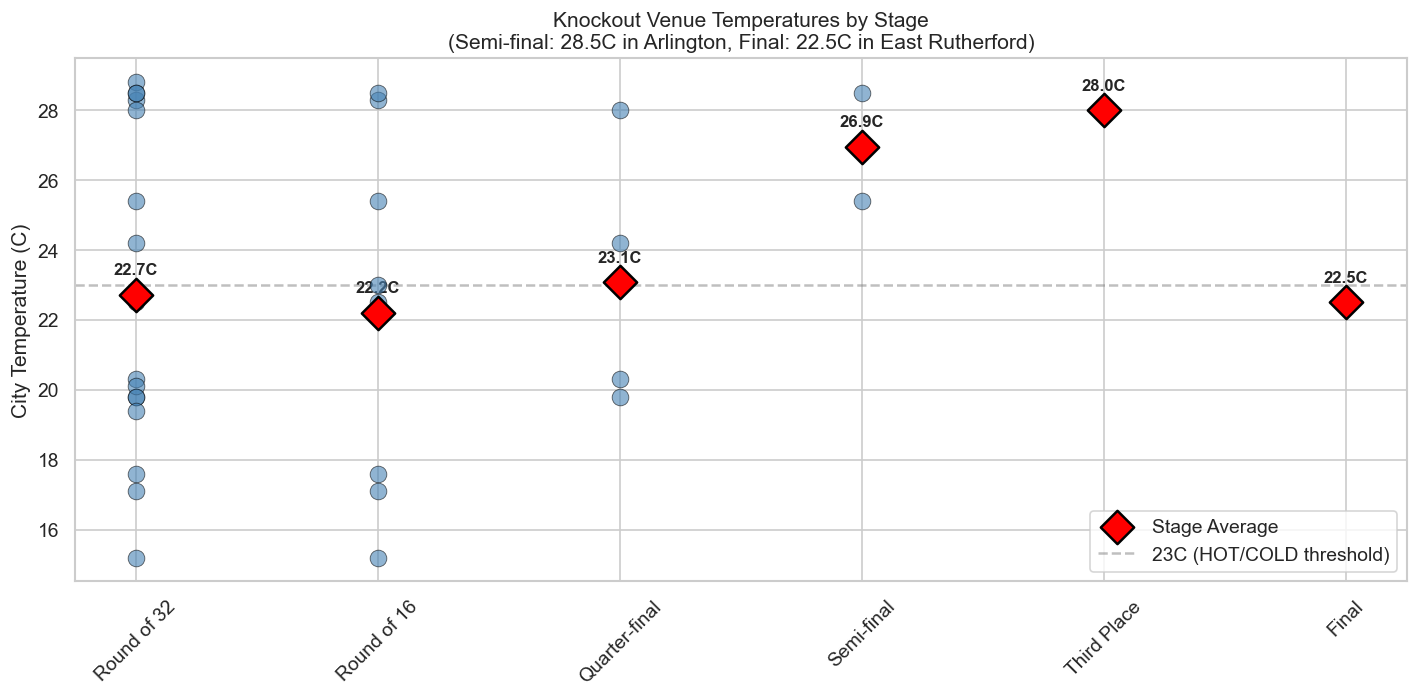

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))

stage_order = ['Round of 32', 'Round of 16', 'Quarter-final', 'Semi-final', 'Third Place', 'Final']
colors = ['steelblue'] * 4 + ['coral', 'coral']
stage_avg = venues.groupby('Stage')['City_Temp_C'].mean()

for stage, color in zip(stage_order, colors):
    subset = venues[venues['Stage'] == stage]
    ax.scatter([stage] * len(subset), subset['City_Temp_C'], 
               alpha=0.6, s=100, color=color, edgecolors='black', linewidth=0.5, zorder=5)

# Stage averages
ax.scatter(stage_order, [stage_avg[s] for s in stage_order], 
           marker='D', s=200, color='red', edgecolors='black', linewidth=1.5, zorder=10, label='Stage Average')

for s in stage_order:
    if s in stage_avg.index:
        ax.annotate(f'{stage_avg[s]:.1f}C', (s, stage_avg[s]), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=23, color='gray', linestyle='--', alpha=0.5, label='23C (HOT/COLD threshold)')
ax.set_ylabel('City Temperature (C)')
ax.set_title('Knockout Venue Temperatures by Stage\n(Semi-final: 28.5C in Arlington, Final: 22.5C in East Rutherford)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## 3. Hot vs Cold Match Distribution

HOT_COLD
COLD    17
HOT     15
Name: count, dtype: int64


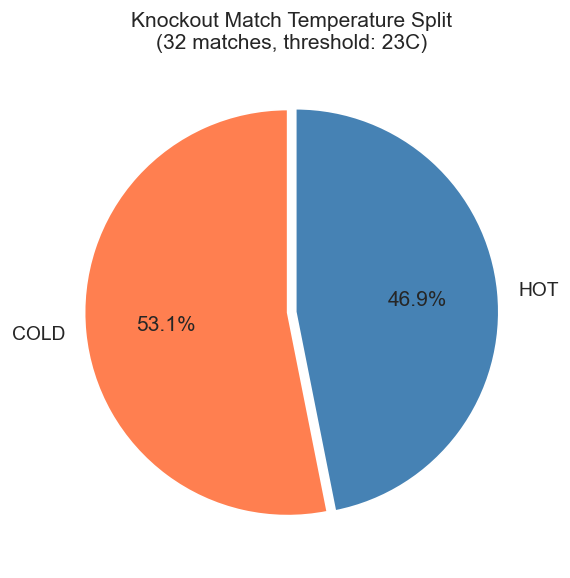

In [3]:
hot_cold_counts = venues['HOT_COLD'].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(hot_cold_counts.values, labels=hot_cold_counts.index, autopct='%1.1f%%',
       colors=['coral', 'steelblue'], startangle=90, explode=(0.02, 0.02))
ax.set_title(f'Knockout Match Temperature Split\n({len(venues)} matches, threshold: 23C)')
plt.tight_layout()
print(hot_cold_counts)

## 4. City Temperature Summary

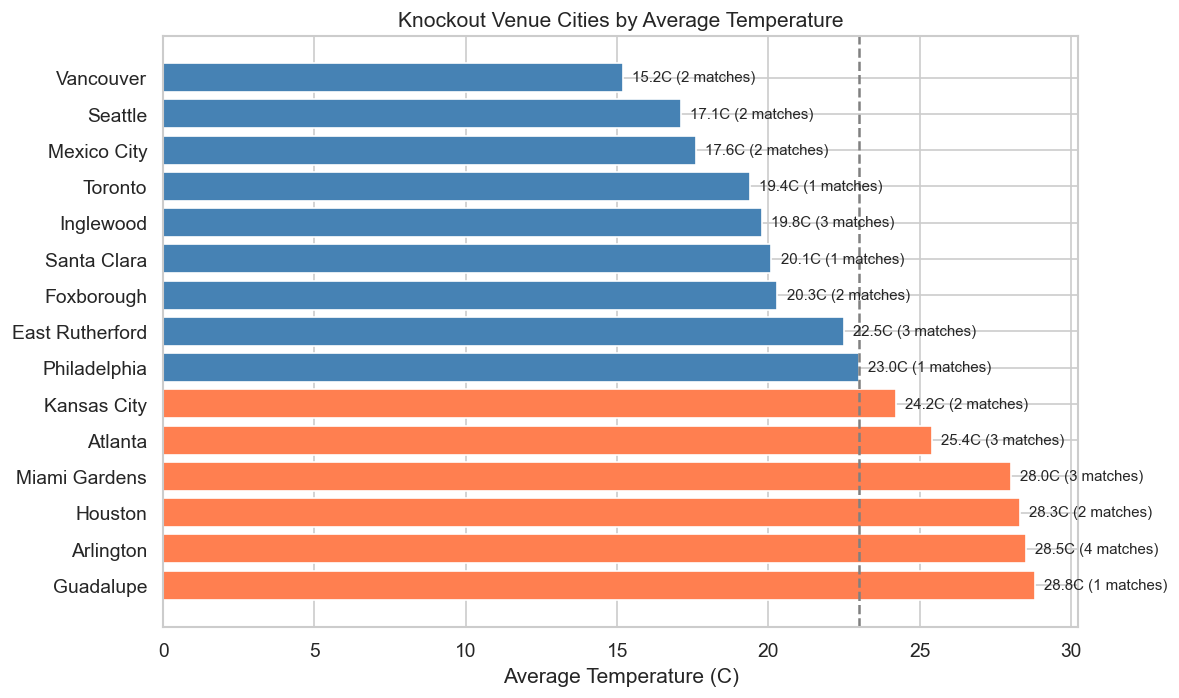

In [4]:
city_summary = venues.groupby('City').agg(
    Matches=('Stage', 'count'),
    Avg_Temp=('City_Temp_C', 'mean'),
).sort_values('Avg_Temp', ascending=False).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
colors_c = ['coral' if t > 23 else 'steelblue' for t in city_summary['Avg_Temp']]
ax.barh(city_summary.index, city_summary['Avg_Temp'], color=colors_c, edgecolor='white')

for i, (city, row) in enumerate(city_summary.iterrows()):
    ax.text(row['Avg_Temp'] + 0.3, i, f'{row["Avg_Temp"]:.1f}C ({int(row["Matches"])} matches)', va='center', fontsize=9)

ax.axvline(x=23, color='gray', linestyle='--')
ax.set_xlabel('Average Temperature (C)')
ax.set_title('Knockout Venue Cities by Average Temperature')
plt.tight_layout()

## 5. Summary

In [5]:
print('KNOCKOUT VENUE SUMMARY')
print('=' * 50)
print(f'Total knockout matches: {len(venues)}')
print(f'Temperature range: {venues["City_Temp_C"].min():.0f} - {venues["City_Temp_C"].max():.0f} C')
print(f'Average: {venues["City_Temp_C"].mean():.1f} C')
print()

print('Hottest venues:')
hot = city_summary.head(4)
for city, row in hot.iterrows():
    print(f'  {city:<25} {row["Avg_Temp"]:.1f}C ({int(row["Matches"])} matches)')

print('\nColdest venues:')
cold = city_summary.tail(4)
for city, row in cold.iterrows():
    print(f'  {city:<25} {row["Avg_Temp"]:.1f}C ({int(row["Matches"])} matches)')

print(f'\nFinal: {venues[venues["Stage"]=="Final"]["City"].values[0]} ({venues[venues["Stage"]=="Final"]["City_Temp_C"].values[0]:.1f}C)')
print(f'Semi 1: {venues[venues["Stage"]=="Semi-final"].iloc[0]["City"]} ({venues[venues["Stage"]=="Semi-final"].iloc[0]["City_Temp_C"]:.1f}C)')
print(f'Semi 2: {venues[venues["Stage"]=="Semi-final"].iloc[1]["City"]} ({venues[venues["Stage"]=="Semi-final"].iloc[1]["City_Temp_C"]:.1f}C)')

KNOCKOUT VENUE SUMMARY
Total knockout matches: 32
Temperature range: 15 - 29 C
Average: 23.1 C

Hottest venues:
  Guadalupe                 28.8C (1 matches)
  Arlington                 28.5C (4 matches)
  Houston                   28.3C (2 matches)
  Miami Gardens             28.0C (3 matches)

Coldest venues:
  Toronto                   19.4C (1 matches)
  Mexico City               17.6C (2 matches)
  Seattle                   17.1C (2 matches)
  Vancouver                 15.2C (2 matches)

Final: East Rutherford (22.5C)
Semi 1: Arlington (28.5C)
Semi 2: Atlanta (25.4C)
